In [50]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from config import *
import pandas as pd
pd.options.display.max_columns = None
import numpy as np

In [116]:
# data = pd.read_csv(os.path.join(DATA_RAW_DIR, 'MELBOURNE_HOUSE_PRICES_LESS.csv'))
df = pd.read_csv(os.path.join(DATA_EXTERNAL_DIR, 'data_joins.csv'))

In [117]:
df['fec_venta'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce').dt.strftime('%Y%m')
df['anio_construccion'] = df['YearBuilt'].astype('Int64')
df['metodo'] = df['Method'].str.strip().map({
    'S':  'prop_vendida',
    'SP': 'prop_vendida_prev',
    'PI': 'prop_transferida',
    'PN': 'vendida_prev_no_divulgada',
    'SN': 'vendida_no_divulgada',
    'VB': 'puja_del_vendedor',
    'W':  'retirada_antes_subasta',
    'SA': 'vendida_despues_subasta',
    'SS': 'vendida_despues_subasta_no_divulgada'
}).fillna('otro')
df['target'] = df['Price']
df = df[df['Price'].notna() & df['Regionname'].notna()]

df['target'] = np.log1p(df.target)

df.drop(columns=['Date', 'Postcode', 'Method', 'SellerG', 'BuildingArea', 'YearBuilt', 'anio_construccion'], axis = 1 , inplace=True, errors='ignore')

In [118]:
var_category = ['Suburb', 'Address', 'Type', 'CouncilArea', 'Regionname', 'metodo' , 'fec_venta']
var_numeric = [i for i in df.columns.to_list() if i not in var_category]
for var in var_category:
    df[var] = df[var].astype('category')

for var in var_numeric:
    df[var] = df[var].astype(float)

In [126]:
def analyze_outliers_mixed_data(df, numerical_cols, categorical_cols, contamination=0.05, plot=True):
    from sklearn.preprocessing import StandardScaler
    from sklearn.ensemble import IsolationForest
    from prince import FAMD
    import matplotlib.pyplot as plt
  
    # Copiar datos originales
    data = df[numerical_cols + categorical_cols].copy()

    scaler = StandardScaler()
    data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

    # Preparar los datos combinados
    data_encoded = data[numerical_cols + categorical_cols]

    # Aplicar FAMD (Factor Analysis of Mixed Data)
    famd = FAMD(n_components=2, random_state=42)
    famd_result = famd.fit_transform(data_encoded)

    # Isolation Forest para detectar outliers
    iso_forest = IsolationForest(
        contamination=contamination,
        n_estimators=50,
        max_samples=0.5,
        max_features=0.8,
        random_state=42
    )
    data['Outlier'] = iso_forest.fit_predict(famd_result)

    # Crear gráficos
    if plot:
        plt.figure(figsize=(10, 6))
        plt.scatter(famd_result.iloc[:, 0], famd_result.iloc[:, 1], c=data['Outlier'], cmap='bwr', s=20)
        plt.title('Proyección FAMD: Detección de Outliers con Isolation Forest')
        plt.xlabel('FAMD Componente 1')
        plt.ylabel('FAMD Componente 2')
        plt.colorbar(label='Outlier (-1: Sí, 1: No)')
        plt.show()

    # Filtrar outliers
    cleaned_data = df[data['Outlier'] == 1]

    print(f"Outliers detectados y eliminados: {len(df) - len(cleaned_data)}")
    return cleaned_data, scaler, famd, iso_forest

In [127]:
df = df.dropna()

In [128]:
df.isnull().sum()

Suburb                        0
Address                       0
Rooms                         0
Type                          0
Price                         0
Distance                      0
Bedroom2                      0
Bathroom                      0
Car                           0
Landsize                      0
CouncilArea                   0
Lattitude                     0
Longtitude                    0
Regionname                    0
Propertycount                 0
Comercio y servicios          0
Restauración y vida social    0
Transporte y conectividad     0
Cultura y recreación          0
Financiero                    0
Espiritual y comunitario      0
Salud                         0
Educación                     0
fec_venta                     0
metodo                        0
target                        0
dtype: int64

In [129]:
df.select_dtypes(include = np.number).columns

Index(['Rooms', 'Price', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize',
       'Lattitude', 'Longtitude', 'Propertycount', 'Comercio y servicios',
       'Restauración y vida social', 'Transporte y conectividad',
       'Cultura y recreación', 'Financiero', 'Espiritual y comunitario',
       'Salud', 'Educación', 'target'],
      dtype='object')

In [130]:
df.select_dtypes(exclude = np.number).columns

Index(['Suburb', 'Address', 'Type', 'CouncilArea', 'Regionname', 'fec_venta',
       'metodo'],
      dtype='object')

In [131]:
cleaned_data, scaler, famd, iso_forest = analyze_outliers_mixed_data(
    df, 
    ['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize',
       'Lattitude', 'Longtitude', 'Propertycount', 'Comercio y servicios',
       'Restauración y vida social', 'Transporte y conectividad',
       'Cultura y recreación', 'Financiero', 'Espiritual y comunitario',
       'Salud', 'Educación'], 
    ['Suburb', 'Address', 'Type', 'CouncilArea', 'Regionname', 'fec_venta',
       'metodo'], 
    contamination=0.01, 
    plot=True
)

MemoryError: Unable to allocate 37.5 GiB for an array with shape (17679, 17793) and data type <U32

In [ ]:
cleaned_data

<Axes: xlabel='target', ylabel='Count'>

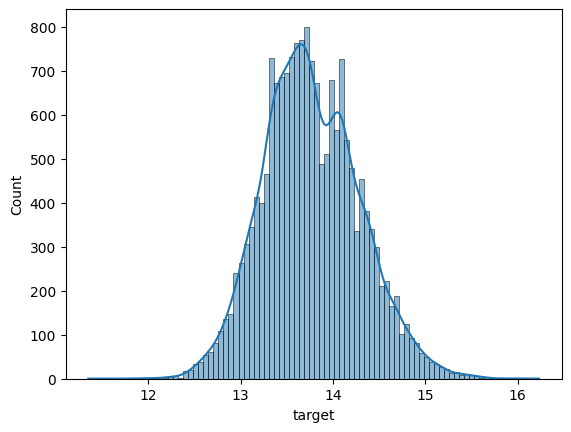

In [ ]:
import seaborn as sns
sns.histplot(data = cleaned_data, x = 'target', kde=True)

$$
\ln \hat{p}^{\tau}_i = \ln \beta_0 + \sum_{k=1}^{K} z^{\tau}_{k,i} \ln \hat{\beta}_k + \sum_{d=1}^{10} \gamma^d D^d + \hat{\varepsilon}_i
$$

**Donde:**

- $i$: es el identificador de cada departamento.
- $k$: es el identificador de cada característica.
- $d$: es el identificador de cada distrito.
- $\ln \hat{p}^{0,\tau}_i$: es el logaritmo del precio de venta del departamento $i$. Se consideran las observaciones desde el periodo 0 hasta el periodo $\tau$.
- $z^{0,\tau}_{k,i}$: es la característica $k$ del departamento $i$. Se consideran las observaciones desde el periodo 0 hasta el periodo $\tau$.
- $\hat{\beta}_k$: es el coeficiente estimado para la característica $k$.
- $D^d$: es la variable binaria de distrito. Captura todas las características diferentes a $Z$ propias de cada distrito $d$.
- $\gamma^d$: es el coeficiente de la variable binaria del distrito $d$.
- $\hat{\varepsilon}_i$: es el error de estimación.


In [108]:
df.target.describe(percentiles=[0.25,0.5,0.75,0.9,0.99])

count    17679.000000
mean        13.765125
std          0.519854
min         11.350418
25%         13.399997
50%         13.723944
75%         14.111905
90%         14.445931
99%         15.056779
max         16.231424
Name: target, dtype: float64

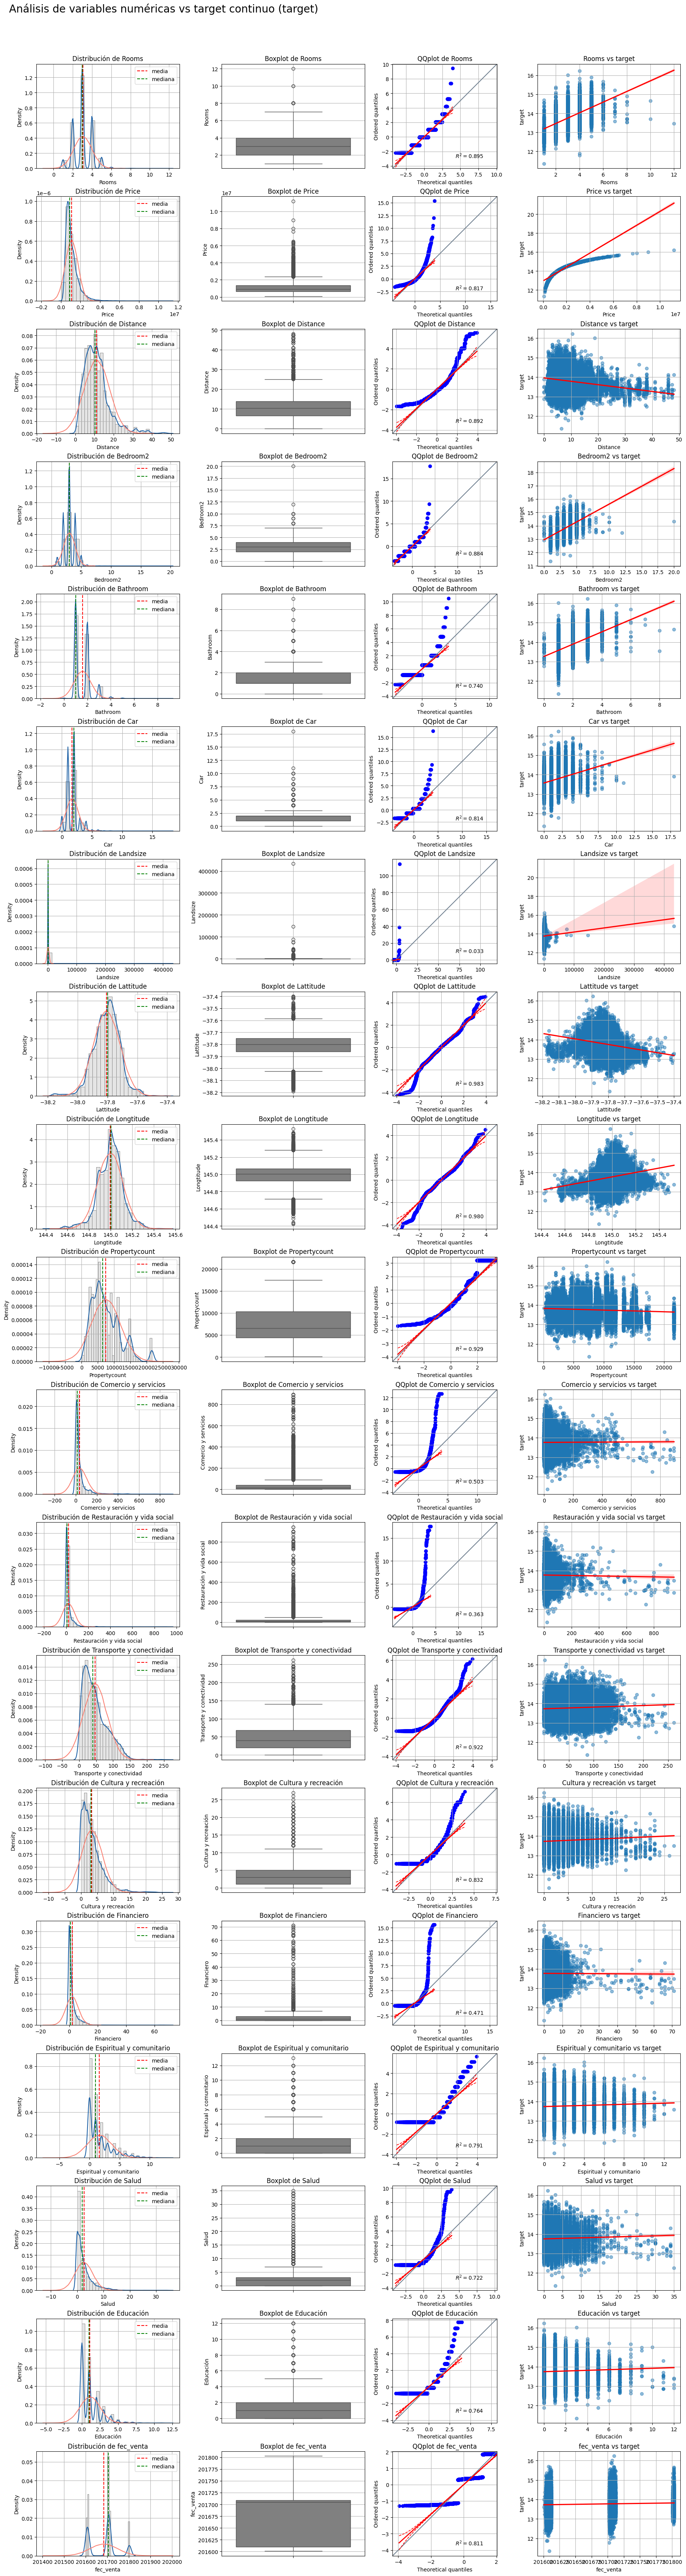

,variable,normal,p_value,correlacion_pearson
0,Rooms,No,3.185841e-183,0.509753
1,Price,No,0.000000e+00,0.925868
2,Distance,No,0.000000e+00,-0.221878
3,Bedroom2,No,0.000000e+00,0.490789
4,Bathroom,No,0.000000e+00,0.427244
5,Car,No,0.000000e+00,0.216976
6,Landsize,No,0.000000e+00,0.031699
7,Lattitude,No,3.964262e-190,-0.242676
8,Longtitude,No,1.344342e-191,0.254771
9,Propertycount,No,0.000000e+00,-0.072858


In [109]:
from src.analysis import analisis_variables_numericas_continuo 
analisis_variables_numericas_continuo(df,'target')